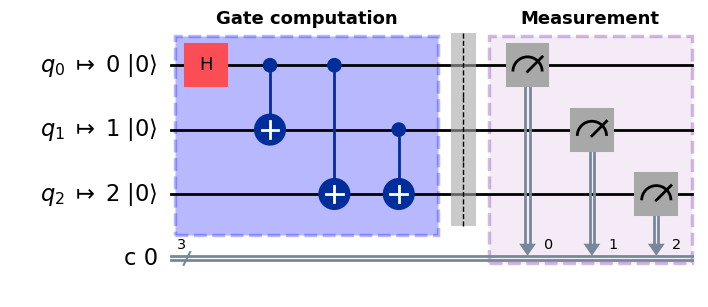

In [1]:
# !pip install qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.converters import circuit_to_dag
from matplotlib.patches import Rectangle
from IPython.display import display
import matplotlib.pyplot as plt

# Build computation as a named block
compute = QuantumCircuit(3, name="Gate computation")
compute.h(0)
compute.cx(0, 1)
compute.cx(0, 2)
compute.cx(1, 2)

# Main circuit with explicit measurement register
qc = QuantumCircuit(3, 3)
qc.append(compute.to_instruction(), [0, 1, 2])
qc.barrier()
qc.measure([0, 1, 2], [0, 1, 2])

# Keep layout labels q_i -> i while preserving H in the drawing
qc_for_draw = transpile(
    qc,
    # coupling_map=[[0, 1], [1, 0], [1, 2], [2, 1]],
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    optimization_level=0,
    basis_gates=["h", "cx", "measure"],
)

# Draw circuit
fig = qc_for_draw.draw("mpl", with_layout=True, fold=-1, initial_state=True, cregbundle=True)
ax = fig.axes[0]
fig.canvas.draw()

# Compute layer ranges for computation vs measurement boxes
dag = circuit_to_dag(qc_for_draw)
layers = list(dag.layers())
n_layers = max(1, len(layers))

def layer_ops(layer_dict):
    graph = layer_dict.get("graph")
    return list(graph.op_nodes()) if graph is not None else []

measure_layers = []
for i, layer in enumerate(layers):
    names = [n.name for n in layer_ops(layer)]
    if any(name == "measure" for name in names):
        measure_layers.append(i)

if not measure_layers:
    measure_layers = [n_layers - 1]

first_measure = min(measure_layers)
last_measure = max(measure_layers)
comp_start = 0
comp_end = max(0, first_measure - 1)

def layer_to_x(l0, l1, pad=0.35):
    x0 = (l0 - pad) / n_layers
    x1 = (l1 + 1 + pad) / n_layers
    return max(0.01, x0), min(0.99, x1)

# Add dashed translucent boxes like the reference image
y0, h = 0.12, 0.80
comp_h = 0.70

cx0, cx1 = layer_to_x(comp_start, comp_end)
mx0, mx1 = layer_to_x(first_measure, last_measure)

# Manual position offsets (axes coordinates: 0..1)
comp_dx = 0.23    # +right, -left (Gate computation box)
comp_dy = 0.10      # +up, -down (Gate computation box)
comp_width_delta = -0.5  # +wider, -narrower (Gate computation box)
meas_dx = -0.08      # +right, -left (Measurement box)
meas_dy = 0.00      # +up, -down (Measurement box)
meas_width_delta = 0.10  # +wider, -narrower (Measurement box)

cx0, cx1 = cx0 + comp_dx, cx1 + comp_dx + comp_width_delta
mx0, mx1 = mx0 + meas_dx, mx1 + meas_dx + meas_width_delta

# Clamp to visible area
cx0, cx1 = max(0.01, cx0), min(0.99, cx1)
mx0, mx1 = max(0.01, mx0), min(0.99, mx1)

# Keep a visible gap between the two boxes
min_gap = 0.02
if cx1 + min_gap > mx0:
    midpoint = (cx1 + mx0) / 2
    cx1 = max(cx0 + 0.02, midpoint - min_gap / 2)
    mx0 = min(mx1 - 0.02, midpoint + min_gap / 2)

comp_box = Rectangle(
    (cx0, y0 + comp_dy), cx1 - cx0, comp_h,
    transform=ax.transAxes,
    facecolor="blue", alpha=0.28,
    edgecolor="blue", linewidth=2.5, linestyle="--",
    zorder=0,
 )
ax.add_patch(comp_box)
ax.text(
    (cx0 + cx1) / 2, y0 + comp_dy + comp_h + 0.03, "Gate computation",
    transform=ax.transAxes, ha="center", va="bottom",
    fontsize=13, fontweight="bold", color="black"
 )

meas_box = Rectangle(
    (mx0, y0 + meas_dy), mx1 - mx0, h,
    transform=ax.transAxes,
    facecolor="#e1bee7", alpha=0.30,
    edgecolor="#6a1b9a", linewidth=2.5, linestyle="--",
    zorder=0,
 )
ax.add_patch(meas_box)
ax.text(
    (mx0 + mx1) / 2, y0 + meas_dy + h + 0.03, "Measurement",
    transform=ax.transAxes, ha="center", va="bottom",
    fontsize=13, fontweight="bold", color="black"
 )

display(fig)
plt.close(fig)

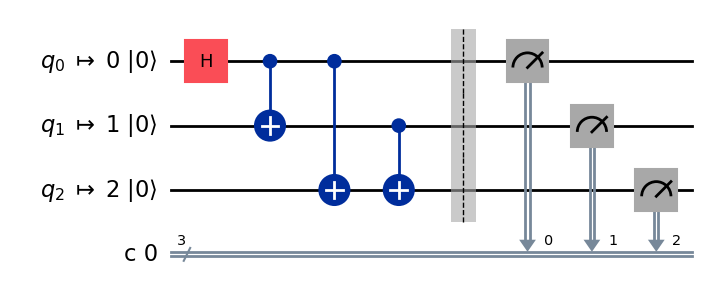

In [2]:
# Build computation as a named block
compute = QuantumCircuit(3, name="Gate computation")
compute.h(0)
compute.cx(0, 1)
compute.cx(0, 2)
compute.cx(1, 2)

# Main circuit with explicit measurement register
qc = QuantumCircuit(3, 3)
qc.append(compute.to_instruction(), [0, 1, 2])
qc.barrier()
qc.measure([0, 1, 2], [0, 1, 2])

# Keep layout labels q_i -> i while preserving H in the drawing
qc_for_draw = transpile(
    qc,
    # coupling_map=[[0, 1], [1, 0], [1, 2], [2, 1]],
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    optimization_level=0,
    basis_gates=["h", "cx", "measure"],
)

# Draw circuit
fig = qc_for_draw.draw("mpl", with_layout=True, fold=-1, initial_state=True, cregbundle=True)
ax = fig.axes[0]
fig.canvas.draw()

display(fig)
plt.close(fig)

Measurement percentages:
  000: 49.63%
  011: 50.37%


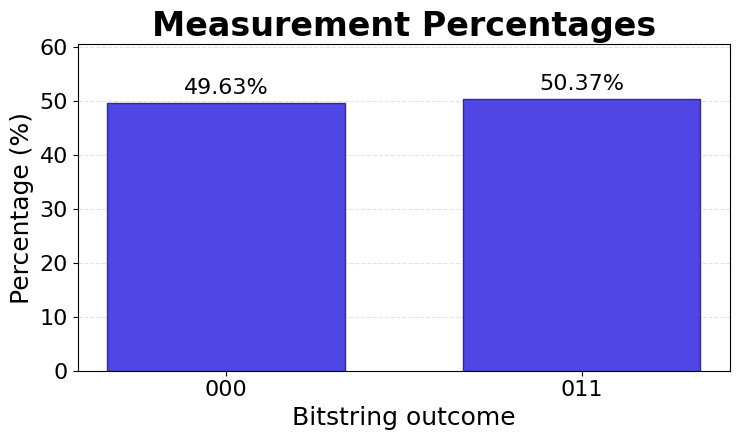

In [3]:
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Run the measured circuit and show percentages
backend = BasicSimulator()
shots = 4098
tqc = transpile(qc, backend)
result = backend.run(tqc, shots=shots).result()
counts = result.get_counts()

# Relative frequencies (probabilities)
total = sum(counts.values())
rel_freq = {state: count / total for state, count in counts.items()}

# Sort states numerically for stable visualization
states = sorted(rel_freq.keys(), key=lambda bitstring: int(bitstring, 2))
percents = [100 * rel_freq[state] for state in states]

print("Measurement percentages:")
for state in states:
    print(f"  {state}: {100 * rel_freq[state]:.2f}%")

# Nicer bar chart
fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Control both bar width and bar gap independently
bar_width = 0.2
center_spacing = 0.3
x = np.arange(len(states)) * center_spacing

bars = ax.bar(x, percents, width=bar_width, color="#4f46e5", edgecolor="#312e81", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(states)

ax.set_title("Measurement Percentages", fontsize=24, fontweight="bold")
ax.set_xlabel("Bitstring outcome", fontsize=18)
ax.set_ylabel("Percentage (%)", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
ax.set_ylim(0, max(percents) * 1.20 if percents else 100)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Annotate bars with percentages
for bar, pct in zip(bars, percents):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=16,
    )

plt.tight_layout()
display(fig)
plt.close(fig)

force_second_swap: True
Measurement wiring (q -> c): [0, 1, 2]
Compiled circuit depth: 9
Compiled circuit gates: OrderedDict([('barrier', 5), ('cx', 3), ('measure', 3), ('rz', 2), ('swap', 2), ('rx', 1)])


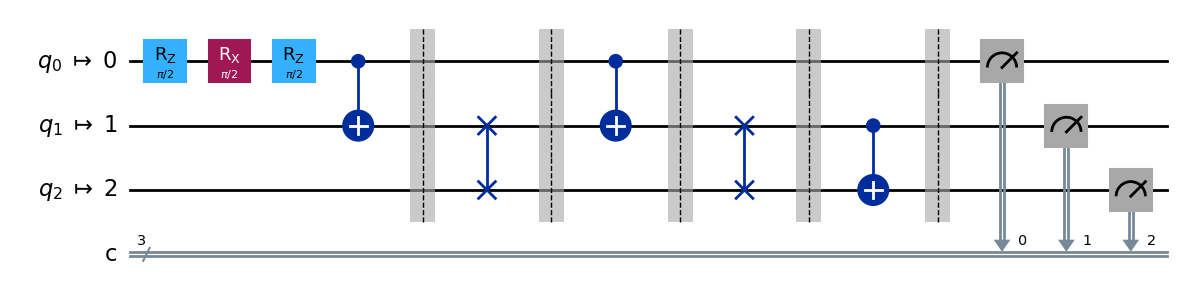

In [89]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
from qiskit.converters import circuit_to_dag
from matplotlib.patches import Rectangle
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# 3-qubit hardware with limited connectivity: 0 <-> 1 <-> 2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Native gate set for compilation
basis_gates = ["rz", "rx", "cx", "swap", "measure"]

# Force an explicit SWAP-back after routing CX(0,2)
force_second_swap = True

qc_for_compile = QuantumCircuit(3, 3)

# Replace H with Rx/Rz decomposition: H ≡ Rz(pi/2) -> Rx(pi/2) -> Rz(pi/2)
qc_for_compile.rz(np.pi / 2, 0)
qc_for_compile.rx(np.pi / 2, 0)
qc_for_compile.rz(np.pi / 2, 0)

# Original logical first gate
qc_for_compile.cx(0, 1)

if force_second_swap:
    # Manual routing for logical CX(0,2) on 0-1-2 chain, explicitly swapping back
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)
    qc_for_compile.barrier()
    qc_for_compile.cx(0, 1)
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)  # explicit second SWAP (swap-back)
    qc_for_compile.barrier()
    qc_for_compile.cx(1, 2)    # original logical final CX after mapping is restored
    qc_for_compile.barrier()
else:
    # Let transpiler route automatically
    qc_for_compile.cx(0, 2)
    qc_for_compile.cx(1, 2)

# Manually force measurement wiring: q[i] -> c[measurement_wiring[i]]
measurement_wiring = [0, 1, 2]
for q, c in enumerate(measurement_wiring):
    qc_for_compile.measure(q, c)

compiled_qc = transpile(
    qc_for_compile,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=0,
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    routing_method="none" if force_second_swap else "basic",
)

print("force_second_swap:", force_second_swap)
print("Measurement wiring (q -> c):", measurement_wiring)
print("Compiled circuit depth:", compiled_qc.depth())
print("Compiled circuit gates:", compiled_qc.count_ops())

# Draw compiled circuit and highlight both 3-CNOT SWAP implementations
fig = compiled_qc.draw("mpl", with_layout=True, fold=-1, cregbundle=True)
ax = fig.axes[0]
fig.canvas.draw()

dag = circuit_to_dag(compiled_qc)
layers = list(dag.layers())
n_layers = max(1, len(layers))

def layer_ops(layer_dict):
    graph = layer_dict.get("graph")
    return list(graph.op_nodes()) if graph is not None else []

# Layers containing a CNOT acting on qubits {1,2}
swap_cx_layers = []
for i, layer in enumerate(layers):
    has_swap_cx = False
    for node in layer_ops(layer):
        if node.name != "cx":
            continue
        q_idx = {compiled_qc.find_bit(q).index for q in node.qargs}
        if q_idx == {1, 2}:
            has_swap_cx = True
            break
    if has_swap_cx:
        swap_cx_layers.append(i)

# Find runs of exactly 3 consecutive layers -> one SWAP decomposition
swap_runs = []
if swap_cx_layers:
    run = [swap_cx_layers[0]]
    for idx in swap_cx_layers[1:]:
        if idx == run[-1] + 1:
            run.append(idx)
        else:
            if len(run) == 3:
                swap_runs.append(run)
            run = [idx]
    if len(run) == 3:
        swap_runs.append(run)

def layer_to_x(l0, l1, pad=0.22):
    x0 = (l0 - pad) / n_layers
    x1 = (l1 + 1 + pad) / n_layers
    return max(0.01, x0), min(0.99, x1)

# Add boxes around both SWAP(1,2) decompositions (3 CNOT each)
y0_box, h_box = 0.24, 0.44
for run in swap_runs[:2]:
    x0_box, x1_box = layer_to_x(run[0], run[-1])
    swap_box = Rectangle(
        (x0_box, y0_box), x1_box - x0_box, h_box,
        transform=ax.transAxes,
        facecolor="#bbdefb", alpha=0.22,
        edgecolor="#1565c0", linewidth=2.0, linestyle="--",
        zorder=0,
    )
    ax.add_patch(swap_box)

display(fig)
plt.close(fig)

force_second_swap: True
Measurement wiring (q -> c): [0, 1, 2]
Compiled circuit depth: 13
Compiled circuit gates: OrderedDict([('cx', 9), ('barrier', 5), ('measure', 3), ('rz', 2), ('rx', 1)])


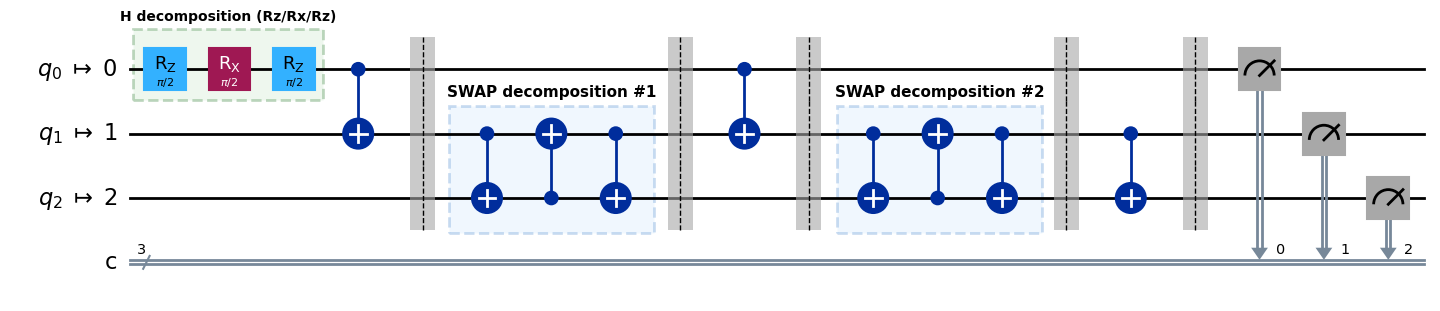

In [127]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
from qiskit.converters import circuit_to_dag
from matplotlib.patches import Rectangle
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# 3-qubit hardware with limited connectivity: 0 <-> 1 <-> 2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Native gate set for compilation
basis_gates = ["rz", "rx", "cx", "measure"]

# Force an explicit SWAP-back after routing CX(0,2)
force_second_swap = True

qc_for_compile = QuantumCircuit(3, 3)

# Replace H with Rx/Rz decomposition: H ≡ Rz(pi/2) -> Rx(pi/2) -> Rz(pi/2)
qc_for_compile.rz(np.pi / 2, 0)
qc_for_compile.rx(np.pi / 2, 0)
qc_for_compile.rz(np.pi / 2, 0)

# Original logical first gate
qc_for_compile.cx(0, 1)

if force_second_swap:
    # Manual routing for logical CX(0,2) on 0-1-2 chain, explicitly swapping back
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)
    qc_for_compile.barrier()
    qc_for_compile.cx(0, 1)
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)  # explicit second SWAP (swap-back)
    qc_for_compile.barrier()
    qc_for_compile.cx(1, 2)    # original logical final CX after mapping is restored
    qc_for_compile.barrier()
else:
    # Let transpiler route automatically
    qc_for_compile.cx(0, 2)
    qc_for_compile.cx(1, 2)

# Manually force measurement wiring: q[i] -> c[measurement_wiring[i]]
measurement_wiring = [0, 1, 2]
for q, c in enumerate(measurement_wiring):
    qc_for_compile.measure(q, c)

compiled_qc = transpile(
    qc_for_compile,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=0,
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    routing_method="none" if force_second_swap else "basic",
)

print("force_second_swap:", force_second_swap)
print("Measurement wiring (q -> c):", measurement_wiring)
print("Compiled circuit depth:", compiled_qc.depth())
print("Compiled circuit gates:", compiled_qc.count_ops())

# Draw compiled circuit and then overlay highlight boxes
fig = compiled_qc.draw("mpl", with_layout=True, fold=-1, cregbundle=True)
ax = fig.axes[0]
fig.canvas.draw()

dag = circuit_to_dag(compiled_qc)
layers = list(dag.layers())
n_layers = max(1, len(layers))

def layer_ops(layer_dict):
    graph = layer_dict.get("graph")
    return list(graph.op_nodes()) if graph is not None else []

def layer_to_x(l0, l1, pad):
    x0 = (l0 - pad) / n_layers
    x1 = (l1 + 1 + pad) / n_layers
    return max(0.01, x0), min(0.99, x1)

# --- Detect SWAP decompositions (as 3 consecutive CX gates on qubits {1,2}) ---
swap_cx_layers = []
for i, layer in enumerate(layers):
    has_swap_cx = False
    for node in layer_ops(layer):
        if node.name != "cx":
            continue
        q_idx = {compiled_qc.find_bit(q).index for q in node.qargs}
        if q_idx == {1, 2}:
            has_swap_cx = True
            break
    if has_swap_cx:
        swap_cx_layers.append(i)

# Find runs of exactly 3 consecutive layers -> one SWAP decomposition
swap_runs = []
if swap_cx_layers:
    run = [swap_cx_layers[0]]
    for idx in swap_cx_layers[1:]:
        if idx == run[-1] + 1:
            run.append(idx)
        else:
            if len(run) == 3:
                swap_runs.append(run)
            run = [idx]
    if len(run) == 3:
        swap_runs.append(run)

# --- Detect the Hadamard decomposition on qubit 0 (first run of 3 rz/rx layers) ---
h_rot_layers = []
for i, layer in enumerate(layers):
    for node in layer_ops(layer):
        if node.name not in {"rz", "rx"}:
            continue
        q_idx = {compiled_qc.find_bit(q).index for q in node.qargs}
        if q_idx == {0}:
            h_rot_layers.append(i)
            break

h_run = []
for idx in h_rot_layers:
    if not h_run:
        h_run = [idx]
    elif idx == h_run[-1] + 1:
        h_run.append(idx)
    else:
        h_run = [idx]
    if len(h_run) == 3:
        break

if len(h_run) < 3 and len(h_rot_layers) >= 3:
    h_run = h_rot_layers[:3]

# ===================================================================
# TUNING KNOBS (edit here)
# Keep this block near the end so you can tweak and re-run quickly.
# All values are in axes coordinates: 0..1
# ===================================================================

# SWAP highlight boxes
swap1_pad = -0.2  # width: bigger pad => wider box
swap1_dx = 0.02  # move: +dx => right, -dx => left
swap2_pad = -0.2
swap2_dx = -0.04

swap_y0 = 0.24
swap_h = 0.45

# Hadamard decomposition box (Rz/Rx/Rz)
h_pad = -0.3
h_dx = 0.07
h_y0 = 0.71
h_h = 0.25

# --- Draw the Hadamard decomposition box ---
if h_run:
    hx0, hx1 = layer_to_x(h_run[0], h_run[-1], pad=h_pad)
    hx0, hx1 = hx0 + h_dx, hx1 + h_dx
    hx0, hx1 = max(0.01, hx0), min(0.99, hx1)

    h_box = Rectangle(
        (hx0, h_y0), hx1 - hx0, h_h,
        transform=ax.transAxes,
        facecolor="#c8e6c9", alpha=0.30,
        edgecolor="#2e7d32", linewidth=2.0, linestyle="--",
        zorder=0,
    )
    ax.add_patch(h_box)
    ax.text(
        (hx0 + hx1) / 2, h_y0 + h_h + 0.02,
        "H decomposition (Rz/Rx/Rz)",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="black",
    )

# --- Draw the SWAP decomposition boxes ---
for k, run in enumerate(swap_runs[:2], start=1):
    pad = swap1_pad if k == 1 else swap2_pad
    dx = swap1_dx if k == 1 else swap2_dx

    x0_box, x1_box = layer_to_x(run[0], run[-1], pad=pad)
    x0_box, x1_box = x0_box + dx, x1_box + dx

    # Clamp to visible area
    x0_box, x1_box = max(0.01, x0_box), min(0.99, x1_box)

    swap_box = Rectangle(
        (x0_box, swap_y0), x1_box - x0_box, swap_h,
        transform=ax.transAxes,
        facecolor="#bbdefb", alpha=0.22,
        edgecolor="#1565c0", linewidth=2.0, linestyle="--",
        zorder=0,
    )
    ax.add_patch(swap_box)
    ax.text(
        (x0_box + x1_box) / 2, swap_y0 + swap_h + 0.02,
        f"SWAP decomposition #{k}",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="black",
    )

display(fig)
plt.close(fig)

In [ ]:
from qiskit import transpile, QuantumCircuit
from qiskit.transpiler import CouplingMap
from qiskit.converters import circuit_to_dag
from matplotlib.patches import Rectangle
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# 3-qubit hardware with limited connectivity: 0 <-> 1 <-> 2
coupling_map = CouplingMap([[0, 1], [1, 0], [1, 2], [2, 1]])

# Native gate set for compilation
basis_gates = ["rz", "rx", "cx", "measure"]

# Force an explicit SWAP-back after routing CX(0,2)
force_second_swap = True

qc_for_compile = QuantumCircuit(3, 3)

# Replace H with Rx/Rz decomposition: H ≡ Rz(pi/2) -> Rx(pi/2) -> Rz(pi/2)
qc_for_compile.rz(np.pi / 2, 0)
qc_for_compile.rx(np.pi / 2, 0)
qc_for_compile.rz(np.pi / 2, 0)

# Original logical first gate
qc_for_compile.cx(0, 1)

if force_second_swap:
    # Manual routing for logical CX(0,2) on 0-1-2 chain, explicitly swapping back
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)
    qc_for_compile.barrier()
    qc_for_compile.cx(0, 1)
    qc_for_compile.barrier()
    qc_for_compile.swap(1, 2)  # explicit second SWAP (swap-back)
    qc_for_compile.barrier()
    qc_for_compile.cx(1, 2)    # original logical final CX after mapping is restored
else:
    # Let transpiler route automatically
    qc_for_compile.cx(0, 2)
    qc_for_compile.cx(1, 2)

# Manually force measurement wiring: q[i] -> c[measurement_wiring[i]]
measurement_wiring = [0, 1, 2]
for q, c in enumerate(measurement_wiring):
    qc_for_compile.measure(q, c)

compiled_qc = transpile(
    qc_for_compile,
    basis_gates=basis_gates,
    coupling_map=coupling_map,
    optimization_level=0,
    initial_layout=[0, 1, 2],
    layout_method="trivial",
    routing_method="none" if force_second_swap else "basic",
)

print("force_second_swap:", force_second_swap)
print("Measurement wiring (q -> c):", measurement_wiring)
print("Compiled circuit depth:", compiled_qc.depth())
print("Compiled circuit gates:", compiled_qc.count_ops())

# Draw compiled circuit and highlight both 3-CNOT SWAP implementations
fig = compiled_qc.draw("mpl", with_layout=True, fold=-1, cregbundle=True)
ax = fig.axes[0]
fig.canvas.draw()

dag = circuit_to_dag(compiled_qc)
layers = list(dag.layers())
n_layers = max(1, len(layers))

def layer_ops(layer_dict):
    graph = layer_dict.get("graph")
    return list(graph.op_nodes()) if graph is not None else []

# Layers containing a CNOT acting on qubits {1,2}
swap_cx_layers = []
for i, layer in enumerate(layers):
    has_swap_cx = False
    for node in layer_ops(layer):
        if node.name != "cx":
            continue
        q_idx = {compiled_qc.find_bit(q).index for q in node.qargs}
        if q_idx == {1, 2}:
            has_swap_cx = True
            break
    if has_swap_cx:
        swap_cx_layers.append(i)

# Find runs of exactly 3 consecutive layers -> one SWAP decomposition
swap_runs = []
if swap_cx_layers:
    run = [swap_cx_layers[0]]
    for idx in swap_cx_layers[1:]:
        if idx == run[-1] + 1:
            run.append(idx)
        else:
            if len(run) == 3:
                swap_runs.append(run)
            run = [idx]
    if len(run) == 3:
        swap_runs.append(run)

# === SWAP box tuning knobs (axes coordinates: 0..1) ===
# Width parameter: bigger pad => wider box
# Move parameter: +dx => move right, -dx => move left
swap1_pad = -0.15
swap1_dx = 0.015

swap2_pad = -0.15
swap2_dx = -0.05

def layer_to_x(l0, l1, pad):
    x0 = (l0 - pad) / n_layers
    x1 = (l1 + 1 + pad) / n_layers
    return max(0.01, x0), min(0.99, x1)

# Add boxes around both SWAP(1,2) decompositions (3 CNOT each)
y0_box, h_box = 0.24, 0.45

for k, run in enumerate(swap_runs[:2], start=1):
    pad = swap1_pad if k == 1 else swap2_pad
    dx = swap1_dx if k == 1 else swap2_dx

    x0_box, x1_box = layer_to_x(run[0], run[-1], pad=pad)
    x0_box, x1_box = x0_box + dx, x1_box + dx

    # Clamp to visible area
    x0_box, x1_box = max(0.01, x0_box), min(0.99, x1_box)

    swap_box = Rectangle(
        (x0_box, y0_box), x1_box - x0_box, h_box,
        transform=ax.transAxes,
        facecolor="#bbdefb", alpha=0.22,
        edgecolor="#1565c0", linewidth=2.0, linestyle="--",
        zorder=0,
    )
    ax.add_patch(swap_box)
    ax.text(
        (x0_box + x1_box) / 2, y0_box + h_box + 0.02,
        f"SWAP decomposition #{k}",
        transform=ax.transAxes,
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="black",
    )

display(fig)
plt.close(fig)


Measurement percentages:
  000: 49.90%
  011: 50.10%


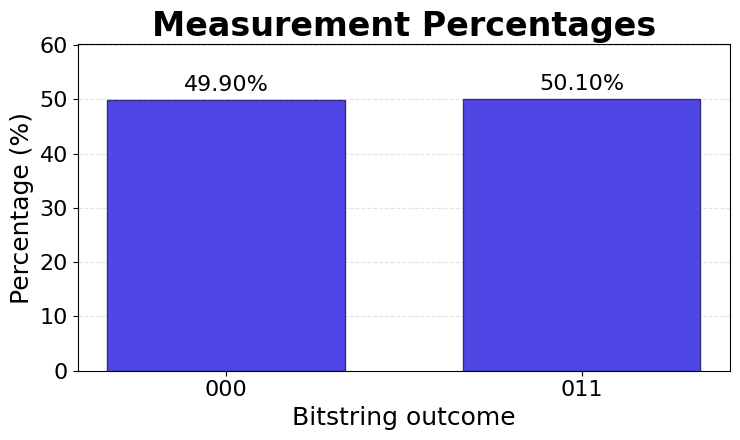

In [6]:
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# Run the measured circuit and show percentages
backend = BasicSimulator()
shots = 4098
tqc = transpile(compiled_qc, backend)

result = backend.run(tqc, shots=shots).result()
counts = result.get_counts()

# Relative frequencies (probabilities)
total = sum(counts.values())
rel_freq = {state: count / total for state, count in counts.items()}

# Sort states numerically for stable visualization
states = sorted(rel_freq.keys(), key=lambda bitstring: int(bitstring, 2))
percents = [100 * rel_freq[state] for state in states]

print("Measurement percentages:")
for state in states:
    print(f"  {state}: {100 * rel_freq[state]:.2f}%")

# Nicer bar chart
fig, ax = plt.subplots(figsize=(7.5, 4.5))

# Control both bar width and bar gap independently
bar_width = 0.2
center_spacing = 0.3
x = np.arange(len(states)) * center_spacing

bars = ax.bar(x, percents, width=bar_width, color="#4f46e5", edgecolor="#312e81", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels(states)

ax.set_title("Measurement Percentages", fontsize=24, fontweight="bold")
ax.set_xlabel("Bitstring outcome", fontsize=18)
ax.set_ylabel("Percentage (%)", fontsize=18)
ax.tick_params(axis="both", labelsize=16)
ax.set_ylim(0, max(percents) * 1.20 if percents else 100)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

# Annotate bars with percentages
for bar, pct in zip(bars, percents):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=16,
    )

plt.tight_layout()
display(fig)
plt.close(fig)

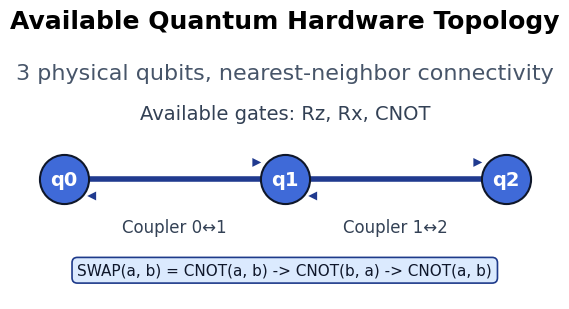

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Assumed hardware topology: 3 qubits with limited connectivity 0 <-> 1 <-> 2
positions = {0: (0.0, 0.0), 1: (1.6, 0.0), 2: (3.2, 0.0)}
connections = [(0, 1), (1, 2)]

fig, ax = plt.subplots(figsize=(6, 3.2))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f7f9fc")

# Draw couplers (line + bidirectional arrows)
for left, right in connections:
    x1, y1 = positions[left]
    x2, y2 = positions[right]

    ax.plot([x1, x2], [y1, y2], color="#203a8f", linewidth=4, solid_capstyle="round", zorder=1)

    arrow_fwd = FancyArrowPatch((x1 + 0.15, y1 + 0.07), (x2 - 0.15, y2 + 0.07),
                                arrowstyle="-|>", mutation_scale=16, lw=0, color="#203a8f", zorder=2)
    arrow_bwd = FancyArrowPatch((x2 - 0.15, y2 - 0.07), (x1 + 0.15, y1 - 0.07),
                                arrowstyle="-|>", mutation_scale=16, lw=0, color="#203a8f", zorder=2)
    ax.add_patch(arrow_fwd)
    ax.add_patch(arrow_bwd)

# Draw qubit nodes
for qubit, (x, y) in positions.items():
    ax.scatter(x, y, s=1250, color="#3f6ad8", edgecolors="#0f172a", linewidths=1.5, zorder=3)
    ax.text(x, y, f"q{qubit}", color="white", ha="center", va="center", fontsize=14, weight="bold", zorder=4)

# Annotate couplers
ax.text(0.8, -0.2, "Coupler 0↔1", ha="center", va="center", fontsize=12, color="#334155")
ax.text(2.4, -0.2, "Coupler 1↔2", ha="center", va="center", fontsize=12, color="#334155")

ax.set_title("Available Quantum Hardware Topology", fontsize=18, weight="bold", pad=14)
ax.text(1.6, 0.42, "3 physical qubits, nearest-neighbor connectivity", ha="center", fontsize=16, color="#475569")
ax.text(1.6, 0.25, "Available gates: Rz, Rx, CNOT", ha="center", fontsize=14, color="#334155")

swap_note = "SWAP(a, b) = CNOT(a, b) -> CNOT(b, a) -> CNOT(a, b)"
ax.text(1.6, -0.38, swap_note, ha="center", va="center", fontsize=11, color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#dbeafe", edgecolor="#1e3a8a", linewidth=1.2))

ax.set_xlim(-0.2, 3.4)
ax.set_ylim(-0.5, 0.55)
ax.axis("off")
plt.tight_layout()
plt.show()

## Decomposition of the Hadamard gate `H`

The initial design keeps `H` explicitly. For compilation (where `H` is unavailable), we use an equivalent Rx/Rz decomposition.

A standard identity is:

$$
H = e^{i\pi/2}\; R_z\left(\frac{\pi}{2}\right)\; R_x\left(\frac{\pi}{2}\right)\; R_z\left(\frac{\pi}{2}\right)
$$

- The global phase $e^{i\pi/2}$ does not affect measurement probabilities.
- Operationally, we replace `H` with `Rz(π/2) -> Rx(π/2) -> Rz(π/2)`.
- This is why the compiled circuit uses `rz` and `rx` instead of a direct `h` gate.

Reference gate: H


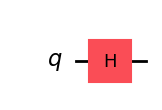

Decomposition: Rz(π/2) -> Rx(π/2) -> Rz(π/2)


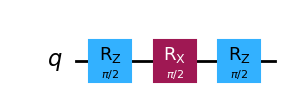

Equivalent up to global phase: True
Max |ΔU|: 1.74e-16


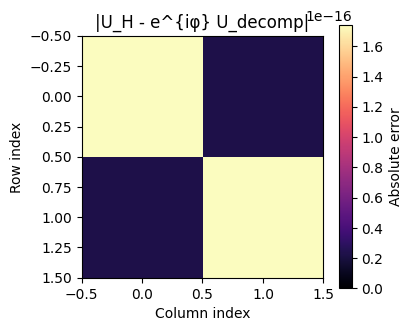

In [8]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Compare ONLY the H gate with its Rx/Rz decomposition
h_ref = QuantumCircuit(1)
h_ref.h(0)

h_decomp = QuantumCircuit(1)
h_decomp.rz(np.pi / 2, 0)
h_decomp.rx(np.pi / 2, 0)
h_decomp.rz(np.pi / 2, 0)

print("Reference gate: H")
display(h_ref.draw("mpl"))
print("Decomposition: Rz(π/2) -> Rx(π/2) -> Rz(π/2)")
display(h_decomp.draw("mpl"))

# Unitary equivalence check up to global phase
u_ref = Operator(h_ref).data
u_decomp = Operator(h_decomp).data

inner = np.vdot(u_decomp.flatten(), u_ref.flatten())
phase = inner / np.abs(inner) if np.abs(inner) > 0 else 1.0
u_aligned = phase * u_decomp
delta = u_ref - u_aligned

is_equivalent = np.allclose(delta, 0, atol=1e-10)
print(f"Equivalent up to global phase: {is_equivalent}")
print(f"Max |ΔU|: {np.max(np.abs(delta)):.2e}")

# Visualize absolute matrix difference (2x2)
fig, ax = plt.subplots(figsize=(4.2, 3.5))
im = ax.imshow(np.abs(delta), cmap="magma", vmin=0)
ax.set_title("|U_H - e^{iφ} U_decomp|")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
fig.colorbar(im, ax=ax, label="Absolute error")
plt.tight_layout()
plt.show()

## Decomposition of the SWAP gate `SWAP`

Like the Hadamard section, we compare the gate with an equivalent decomposition used during compilation.

A standard identity is:

$$
\mathrm{SWAP}(a,b)=\mathrm{CNOT}(a,b)\;\mathrm{CNOT}(b,a)\;\mathrm{CNOT}(a,b)
$$

- This decomposition uses only CNOT operations.
- It explains why routing/compilation can replace a SWAP with three CNOT gates.
- Below, we verify unitary equivalence numerically.

Reference gate: SWAP


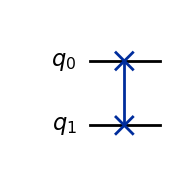

Decomposition: CNOT(0,1) -> CNOT(1,0) -> CNOT(0,1)


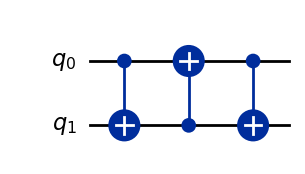

Equivalent up to global phase: True
Max |ΔU|: 0.00e+00


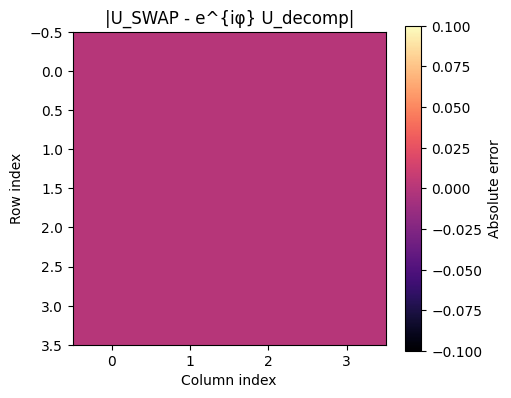

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Compare ONLY the SWAP gate with its 3-CNOT decomposition
swap_ref = QuantumCircuit(2)
swap_ref.swap(0, 1)

swap_decomp = QuantumCircuit(2)
swap_decomp.cx(0, 1)
swap_decomp.cx(1, 0)
swap_decomp.cx(0, 1)

print("Reference gate: SWAP")
display(swap_ref.draw("mpl"))
print("Decomposition: CNOT(0,1) -> CNOT(1,0) -> CNOT(0,1)")
display(swap_decomp.draw("mpl"))

# Unitary equivalence check up to global phase
u_ref = Operator(swap_ref).data
u_decomp = Operator(swap_decomp).data

inner = np.vdot(u_decomp.flatten(), u_ref.flatten())
phase = inner / np.abs(inner) if np.abs(inner) > 0 else 1.0
u_aligned = phase * u_decomp
delta = u_ref - u_aligned

is_equivalent = np.allclose(delta, 0, atol=1e-10)
print(f"Equivalent up to global phase: {is_equivalent}")
print(f"Max |ΔU|: {np.max(np.abs(delta)):.2e}")

# Visualize absolute matrix difference (4x4)
fig, ax = plt.subplots(figsize=(5.2, 4.2))
im = ax.imshow(np.abs(delta), cmap="magma", vmin=0)
ax.set_title("|U_SWAP - e^{iφ} U_decomp|")
ax.set_xlabel("Column index")
ax.set_ylabel("Row index")
fig.colorbar(im, ax=ax, label="Absolute error")
plt.tight_layout()
plt.show()